In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
ds = '/Users/irfanakram/Documents/GitHub/Irfan6200/Portfolio Submission COMP6200/portfolio-part-4-Irfan13/heart.csv'

The following dataset contains 11 features that can be used to predict a possible heart disease.



In [4]:
#Creating a dataframe from the given dataset
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [154]:
#Checking info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [155]:
#Checking for null values
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [156]:
# Remove rows with missing values
df = df.dropna()
df.shape

(918, 12)

In [157]:
#checking again for null values
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [158]:
from sklearn.preprocessing import OrdinalEncoder

#Converting string data variables into numerical data for carrying out correlation
ord_enc = OrdinalEncoder()
df[['Sex']] = ord_enc.fit_transform(df[['Sex']])
df[['ChestPainType']] = ord_enc.fit_transform(df[['ChestPainType']])
df[['RestingECG']] = ord_enc.fit_transform(df[['RestingECG']])
df[['ExerciseAngina']] = ord_enc.fit_transform(df[['ExerciseAngina']])
df[['ST_Slope']] = ord_enc.fit_transform(df[['ST_Slope']])
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1.0,1.0,140,289,0,1.0,172,0.0,0.0,2.0,0
1,49,0.0,2.0,160,180,0,1.0,156,0.0,1.0,1.0,1
2,37,1.0,1.0,130,283,0,2.0,98,0.0,0.0,2.0,0
3,48,0.0,0.0,138,214,0,1.0,108,1.0,1.5,1.0,1
4,54,1.0,2.0,150,195,0,1.0,122,0.0,0.0,2.0,0


In [159]:
#Checking for correlation between Heart Disease and other features

correlations = df.corr().loc['HeartDisease']
correlations


Age               0.282039
Sex               0.305445
ChestPainType    -0.386828
RestingBP         0.107589
Cholesterol      -0.232741
FastingBS         0.267291
RestingECG        0.057384
MaxHR            -0.400421
ExerciseAngina    0.494282
Oldpeak           0.403951
ST_Slope         -0.558771
HeartDisease      1.000000
Name: HeartDisease, dtype: float64

From the correlation data it can be observed that 3 features are the most correlated with Heart Disease: 
1. ST_Slope: -0.558771 (moderate negative correlation, but the most correlated amongst the 11 variables).
2. ExerciseAngina:  0.494282 (moderate positive correlation, 2nd most correlated amongst the 11 variables).
3. OldPeak: 0.403951 (weak positive correlation, 3rd most correlated amongst the 11 variables). 

In [160]:
#Taking the neccesary features (3 most correlated variables and Heart Disease) for test train split
#Creating a sub data frame with with most correlated features and the value to be predicted 
parameters = ['Oldpeak','ExerciseAngina','ST_Slope','HeartDisease']
correlated_data = df[parameters]
correlated_data

,Oldpeak,ExerciseAngina,ST_Slope,HeartDisease
0,0.0,0.0,2.0,0
1,1.0,0.0,1.0,1
2,0.0,0.0,2.0,0
3,1.5,1.0,1.0,1
4,0.0,0.0,2.0,0
...,...,...,...,...
913,1.2,0.0,1.0,1
914,3.4,0.0,1.0,1
915,1.2,1.0,1.0,1
916,0.0,0.0,1.0,1


In [161]:
#Splitting the data into training and test sets
#Dependent and independent variable split. 
X =  correlated_data[['Oldpeak','ExerciseAngina','ST_Slope']]
y = correlated_data['HeartDisease']


X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [162]:
#Checking the shape of test and training data
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (734, 3)
y_train shape: (734,)
X_test shape: (184, 3)
y_test shape: (184,)


In [163]:
# Training the data using Logistic Regression
loReg = LogisticRegression()
loReg.fit(X_train,y_train)

LogisticRegression()

In [164]:
#Assessing the accuracy scores for both training and test data


test_accuracy = loReg.score(X_test, y_test)
train_accuracy = loReg.score(X_train, y_train)


print("Logistic Regression Test Data accuracy score", test_accuracy*100)
print("Logistic Regression Train Data accuracy score", train_accuracy*100)

Logistic Regression Test Data accuracy score 72.82608695652173
Logistic Regression Train Data accuracy score 77.79291553133515


The reported accuracy scores for the Logistic Regression model show that the model performs reasonably well on both the training and test datasets. 

The higher accuracy on the training data (77.79%) compared to the test data (72.83%) suggests that the model may have learned to fit closely to the training examples but might struggle slightly with new, unseen data. This difference in performance indicates a potential for overfitting, where the model captures noise or specific patterns from the training data that don't generalize well to other data. 

To improve the model's generalization ability, further tuning or regularization techniques could be applied to reduce overfitting and enhance performance on unseen data while maintaining good performance on the training set.

In [167]:
# Training the data using KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [168]:
#Assessing the accuracy scores for both training and test data

test_accuracy = knn.score(X_test, y_test)
train_accuracy = knn.score(X_train, y_train)


print("KNN Test Data accuracy score", test_accuracy*100)
print("KNN Train Data accuracy score", train_accuracy*100)

KNN Test Data accuracy score 77.71739130434783
KNN Train Data accuracy score 86.64850136239782


The reported accuracy scores for the K-Nearest Neighbors (KNN) model show that it performs relatively well on both the training data (86.65% accuracy) and the test data (77.72% accuracy). 

The higher accuracy on the training data compared to the test data is typical and suggests some degree of overfitting, where the model may be too closely tailored to the specifics of the training dataset. Despite this, the difference in accuracy between training and test data is not excessively large, indicating that the model is fairly effective at generalizing its predictions to new, unseen data. 

The KNN model's ability to achieve an accuracy of about 77.72% on the test data suggests it is performing reasonably well for the task, but optimizing the model further to reduce overfitting and improve generalization could potentially enhance its performance on new data.

##### Comparison of models

Test Data Performance:
The KNN model (77.72% accuracy) slightly outperforms the Logistic Regression model (72.83% accuracy) on the test dataset. However, both models exhibit a gap between their training and test accuracies, indicating potential overfitting in both cases.

Training Data Performance:
The KNN model achieves a higher accuracy (86.65%) on the training data compared to the Logistic Regression model (77.79%), suggesting that KNN fits the training data more closely.

Text(0, 0.5, 'Heart Disease')

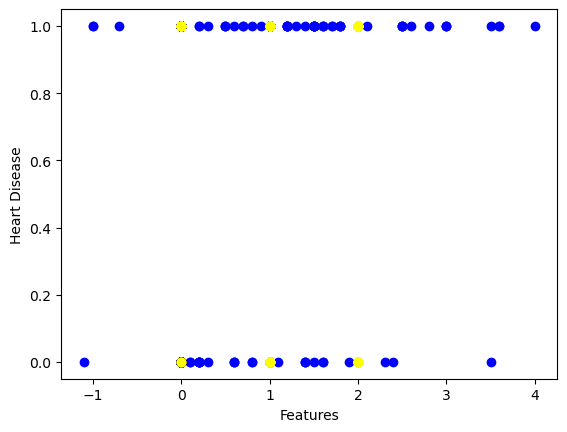

In [171]:
#Visualizing our data via scatterplot
# Plot data set 1
plt.scatter(X_test['Oldpeak'], y_test,c ='blue', label='Data 1')

# Plot data set 2
plt.scatter(X_test['ExerciseAngina'], y_test,c ='black', label='Data 2')

# Plot data set 3
plt.scatter(X_test['ST_Slope'], y_test,c ='yellow', label='Data 3')

plt.xlabel('Features')
plt.ylabel('Heart Disease')

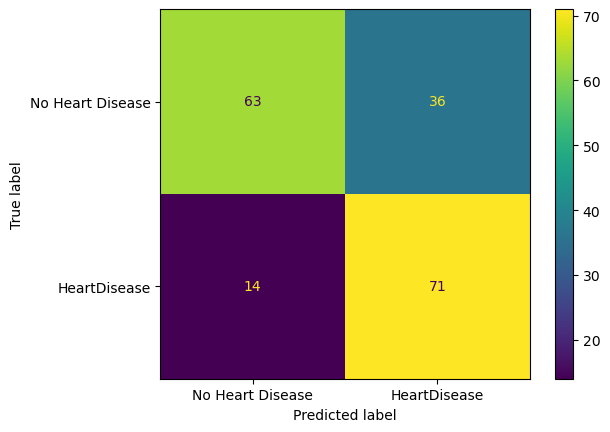

In [170]:
#Creating a confusion matrix to check our true values.
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test_pred, y_test, display_labels=['No Heart Disease', 'HeartDisease'])
plt.show()

From the confusion matrix, it can be calculated that accuracy of the model in terms of correctly predicting is : '134 divided by 184' hence 72.8%.